In [7]:
%pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [8]:
import sys
print(sys.executable)
import pandas as pd 
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

print("Success!")

/opt/homebrew/Cellar/jupyterlab/4.6.0/libexec/bin/python
Success!


predicting freight cost 

In [9]:
con = sqlite3.connect("/Users/sumanpakira/Desktop/minor_project_6/data/inventory.db")
tables = pd.read_sql_query("select name from sqlite_master where type = 'table'",con)


In [11]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [14]:
for table in tables['name']:
    print("Table name:", table)

    df = pd.read_sql_query(
        f"SELECT * FROM {table} LIMIT 5",
        con
    )

    display(df)

Table name: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name: vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [15]:
vendor_df = pd.read_sql_query("select * from vendor_invoice",con)
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,NaN
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,NaN
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,NaN
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,NaN
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,NaN


In [19]:
vendor_df[["Quantity", "Freight", "Dollars"]].corr()

,Quantity,Freight,Dollars
Quantity,1.000000,0.946550,0.963831
Freight,0.946550,1.000000,0.985141
Dollars,0.963831,0.985141,1.000000


In [40]:
vendor_df['freight_per_unit'] = (
    vendor_df['Freight'] / vendor_df['Quantity']
)
print(vendor_df)

      VendorNumber                   VendorName InvoiceDate  PONumber  \
0              105  ALTAMAR BRANDS LLC           2024-01-04      8124   
1             4466  AMERICAN VINTAGE BEVERAGE    2024-01-07      8137   
2              388  ATLANTIC IMPORTING COMPANY   2024-01-09      8169   
3              480  BACARDI USA INC              2024-01-12      8106   
4              516  BANFI PRODUCTS CORP          2024-01-07      8170   
...            ...                          ...         ...       ...   
5538          9622  WEIN BAUER INC               2025-01-06     13626   
5539          9625  WESTERN SPIRITS BEVERAGE CO  2025-01-10     13661   
5540          3664  WILLIAM GRANT & SONS INC     2025-01-02     13643   
5541          9815  WINE GROUP INC               2025-01-03     13602   
5542         90058  ZORVINO VINEYARDS            2025-01-05     13574   

          PODate     PayDate  Quantity    Dollars  Freight Approval  \
0     2023-12-21  2024-02-16         6     214.26   

In [42]:
low_quantity = vendor_df['Quantity'].quantile(0.25)
high_quantity = vendor_df['Quantity'].quantile(0.75)

print("Q1 (25th percentile):", low_quantity)
print("Q3 (75th percentile):", high_quantity)

Q1 (25th percentile): 83.0
Q3 (75th percentile): 5100.5


In [43]:
low_avg = vendor_df.loc[
    vendor_df['Quantity'] < low_quantity,
    'freight_per_unit'
].mean()

high_avg = vendor_df.loc[
    vendor_df['Quantity'] > high_quantity,
    'freight_per_unit'
].mean()

print("Low quantity avg freight/unit:", low_avg)
print("High quantity avg freight/unit:", high_avg)

Low quantity avg freight/unit: 0.09489854253138316
High quantity avg freight/unit: 0.049077654690759046


In [47]:
x=vendor_df[['Quantity','Dollars']] #fetures 
y=vendor_df['Freight'] #target

vendor_df.describe().round()


,VendorNumber,PONumber,Quantity,Dollars,Freight,freight per unit,freight_per_unit
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,20663.0,10889.0,6059.0,58073.0,296.0,0.0,0.0
std,34582.0,1601.0,14453.0,140234.0,714.0,0.0,0.0
min,2.0,8106.0,1.0,4.0,0.0,0.0,0.0
25%,3089.0,9504.0,83.0,968.0,5.0,0.0,0.0
50%,7240.0,10890.0,423.0,4765.0,25.0,0.0,0.0
75%,10754.0,12276.0,5100.0,44587.0,230.0,0.0,0.0
max,201359.0,13661.0,141660.0,1660436.0,8468.0,3.0,3.0


In [51]:
%pip install scikit-learn
from sklearn.model_selection import train_test_split

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 246.0 kB/s  0:00:32a 0:00:010:00:02:03
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 263.3 kB/s  0:01:15 eta 0:00:010:00:03
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-learn]0m 4/5 [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [52]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [55]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [60]:
model1 = LinearRegression()
model1.fit(x_train, y_train)

model2 = DecisionTreeRegressor(max_depth = 4 ,random_state=42)
model2.fit(x_train, y_train)

model3 = RandomForestRegressor(max_depth = 5,random_state=42)
model3.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [58]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model, x_test, y_test, model_name):
    preds = model.predict(x_test)

    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, preds)*100

    print(f"\n{model_name}")
    print("-" * 30)
    print(f"MAE  : {mae:.2f}")
    print(f"MSE  : {mse:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R²   : {r2:.4f}")

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

In [62]:
evaluate_model(model1, x_test, y_test, "Linear Regression")
evaluate_model(model2, x_test, y_test, "Decision Tree")

evaluate_model(model3, x_test, y_test, "Random Forest")


Linear Regression
------------------------------
MAE  : 24.46
MSE  : 15482.52
RMSE : 124.43
R²   : 97.0020

Decision Tree
------------------------------
MAE  : 38.12
MSE  : 19112.51
RMSE : 138.25
R²   : 96.2991

Random Forest
------------------------------
MAE  : 27.61
MSE  : 19205.25
RMSE : 138.58
R²   : 96.2811


{'Model': 'Random Forest',
 'MAE': 27.60594747682912,
 'MSE': 19205.24887107032,
 'RMSE': np.float64(138.58300354325678),
 'R2': 96.28110671289743}

(1109, 2)


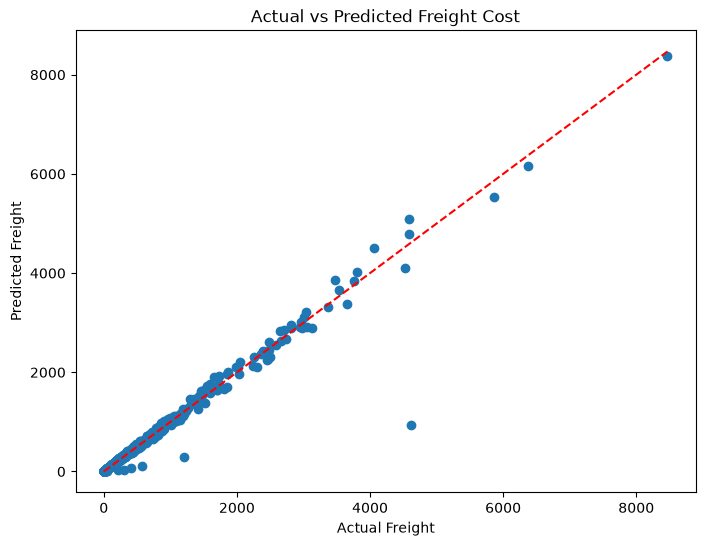

In [67]:
# plt.scatter(x_test , y_test)
# plt.plot(x_test,model1.predict(x_test),color='red')
print(x_test.shape)

y_pred = model1.predict(x_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Freight")
plt.ylabel("Predicted Freight")
plt.title("Actual vs Predicted Freight Cost")
plt.show()


In [70]:
input_data = {
    "Quantity": [1000, 500],
    "Dollars": [18500, 9000]
}

df = pd.DataFrame(input_data)

predictions = model1.predict(df)
print(predictions)

[100.06989033  51.53382746]
